In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq

In [20]:
afib=pd.read_csv('AFib_data.csv')['ECG'].values[1000:2000]
ctrl=pd.read_csv('mimic_perform_non_af_009_data.csv')['ECG'].values[1000:2000]

afib=(afib-np.mean(afib))/np.std(afib)
ctrl=(ctrl-np.mean(ctrl))/np.std(ctrl)

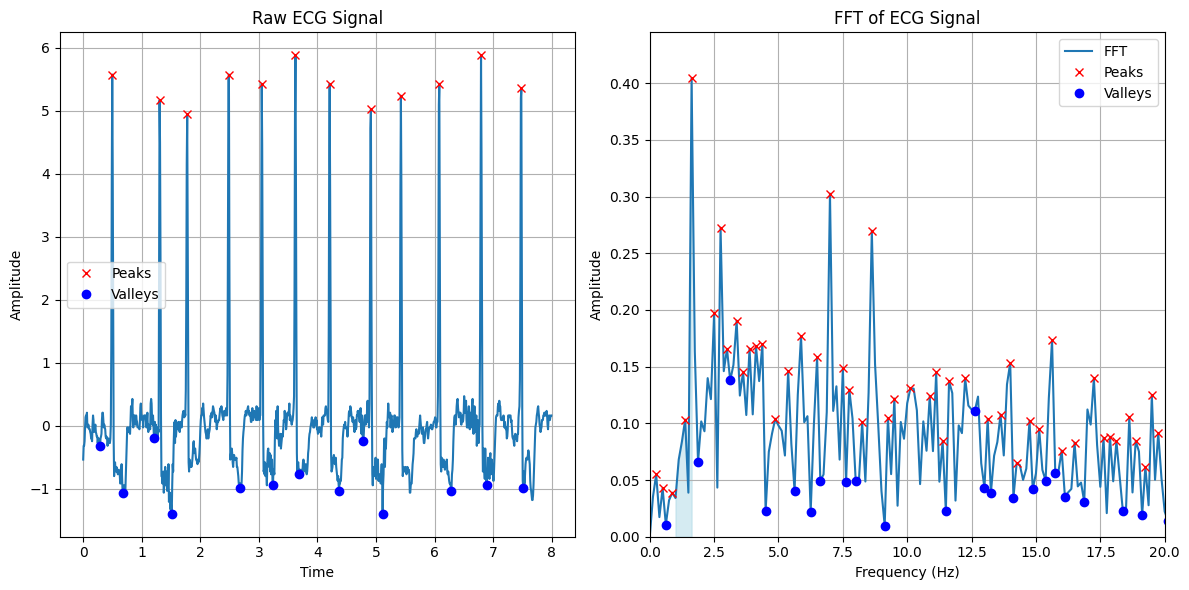

In [21]:
fs=125
N = len(afib)
t = np.arange(N) / fs

# Frequency-domain parameters
yf = fft(afib)
xf = fftfreq(N, 1 / fs)[:N // 2]
yf_processed = 2.0 / N * np.abs(yf[:N // 2])

# Detect peaks and valleys
fft_peaks, _ = find_peaks(2.0/N * np.abs(yf[0:N//2]),
                        height=None, 
                        threshold=None, 
                        distance=None,
                        prominence=0.001,
                        width=0.75,
                        rel_height=0.5)

fft_valleys, _ = find_peaks(-2.0/N * np.abs(yf[0:N//2]),
                        height=None, 
                        threshold=None, 
                        distance=None,
                        prominence=0.001,
                        width=1.5,
                        rel_height=0.5)
# Time domain features
td_peaks, _ = find_peaks(afib,
                        height=1, 
                        threshold=0.005, 
                        distance=0.3*fs,
                        prominence=0.2,
                        width=None,
                        rel_height=None)

td_valleys, _ = find_peaks(-afib,
                        height=None, 
                        threshold=0.01, 
                        distance=0.3*fs,
                        prominence=0.4,
                        width=None,
                        rel_height=None)

# Plot raw signal and its FFT
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Left plot: Raw signal
ax[0].plot(t, afib)
ax[0].plot(t[td_peaks], afib[td_peaks], "x", label="Peaks", color='red')
ax[0].plot(t[td_valleys], afib[td_valleys], "o", label="Valleys", color='blue')
ax[0].set_title('Raw ECG Signal')
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Amplitude')
ax[0].grid()
ax[0].legend()

# Right plot: FFT
ax[1].plot(xf, yf_processed, label='FFT')
ax[1].plot(xf[fft_peaks], yf_processed[fft_peaks], "x", label="Peaks", color='red')
ax[1].plot(xf[fft_valleys], yf_processed[fft_valleys], "o", label="Valleys", color='blue')
ax[1].fill_between(xf, yf_processed, where=(xf >= 1) & (xf <= 1.67), color='lightblue', alpha=0.5)
ax[1].set_xlim([0, 20])
ax[1].set_ylim([0, max(yf_processed) * 1.1])  # Dynamic amplitude limit
ax[1].set_title('FFT of ECG Signal')
ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_ylabel('Amplitude')
ax[1].grid()
ax[1].legend()

plt.tight_layout()
plt.show()

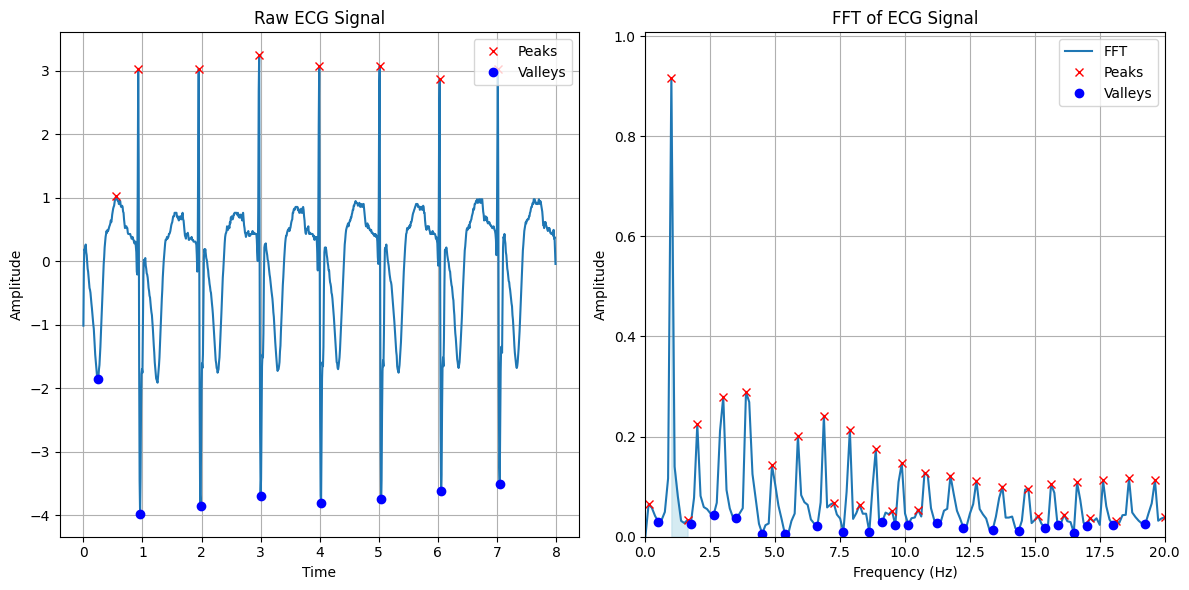

In [22]:
fs=125
N = len(ctrl)
t = np.arange(N) / fs

# Frequency-domain parameters
yf = fft(ctrl)
xf = fftfreq(N, 1 / fs)[:N // 2]
yf_processed = 2.0 / N * np.abs(yf[:N // 2])

# Detect peaks and valleys
fft_peaks, _ = find_peaks(2.0/N * np.abs(yf[0:N//2]),
                        height=None, 
                        threshold=None, 
                        distance=None,
                        prominence=0.001,
                        width=0.75,
                        rel_height=0.5)

fft_valleys, _ = find_peaks(-2.0/N * np.abs(yf[0:N//2]),
                        height=None, 
                        threshold=None, 
                        distance=None,
                        prominence=0.001,
                        width=1.5,
                        rel_height=0.5)
# Time domain features
td_peaks, _ = find_peaks(ctrl,
                        height=1, 
                        threshold=0.005, 
                        distance=0.3*fs,
                        prominence=0.2,
                        width=None,
                        rel_height=None)

td_valleys, _ = find_peaks(-ctrl,
                        height=None, 
                        threshold=0.01, 
                        distance=0.3*fs,
                        prominence=0.4,
                        width=None,
                        rel_height=None)

# Plot raw signal and its FFT
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Left plot: Raw signal
ax[0].plot(t, ctrl)
ax[0].plot(t[td_peaks], ctrl[td_peaks], "x", label="Peaks", color='red')
ax[0].plot(t[td_valleys], ctrl[td_valleys], "o", label="Valleys", color='blue')
ax[0].set_title('Raw ECG Signal')
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Amplitude')
ax[0].grid()
ax[0].legend()

# Right plot: FFT
ax[1].plot(xf, yf_processed, label='FFT')
ax[1].plot(xf[fft_peaks], yf_processed[fft_peaks], "x", label="Peaks", color='red')
ax[1].plot(xf[fft_valleys], yf_processed[fft_valleys], "o", label="Valleys", color='blue')
ax[1].fill_between(xf, yf_processed, where=(xf >= 1) & (xf <= 1.67), color='lightblue', alpha=0.5)
ax[1].set_xlim([0, 20])
ax[1].set_ylim([0, max(yf_processed) * 1.1])  # Dynamic amplitude limit
ax[1].set_title('FFT of ECG Signal')
ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_ylabel('Amplitude')
ax[1].grid()
ax[1].legend()

plt.tight_layout()
plt.show()